# 20250213 HT1080 pPS18 — mitotic duration vs GFP / Texas Red signal

Wells A08, B08, C08 (13 positions), all HT1080 under 500 nM rapamycin +
1 µg/ml doxycycline. 137 frames at 10 min.

What this notebook answers:

1. How `corrected_frames_in_mitosis` depends on the **GFP** and **Texas Red** signal.
2. How it depends on the **cell fate label**.
3. How effective the **background** and **intensity** corrections are —
   signal vs mitotic duration before and after each correction.

**Read section 3 before trusting any corrected number.** The correction maps on
this plate have a problem that the audit there makes explicit, and it changes
how sections 4–6 should be read.

Aggregation goes through `cellaap_aggregate.load_experiment`, which reads
`platemap.csv` through `pipeline`'s own parser, so the groups here are the ones
the run actually analyzed.

## 0. Setup

In [1]:
import sys, os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# The cellaap-analysis checkout, so `import cellaap_aggregate` works from anywhere.
REPO = Path("/Users/ajitjoglekar/Library/CloudStorage/GoogleDrive-ajitj@umich.edu/"
            "My Drive/ImageAnalysis/cellapp-analysis")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import cellaap_aggregate as agg

# ---- experiment configuration -------------------------------------------
ROOT = Path("/Volumes/SharedHITSX/cdb-Joglekar-Lab-GL/precious/20250213/"
            "HT1080 pPS18/2025-02-13/20353")

DELTA_T      = 10      # minutes per frame
EXPT_LENGTH  = 137     # frames in the movie (TimePoint_1 .. TimePoint_137)
CHANNELS     = ["GFP", "Texas Red"]
DURATION     = "corrected_frames_in_mitosis"   # holds MINUTES after load_experiment

# Outputs are written next to this notebook, never into the (read-mostly,
# network-mounted) data folder.
OUTDIR = Path("analysis_outputs/20250213_HT1080_pPS18")
FIGDIR = OUTDIR / "figures"
CACHE  = OUTDIR / "cache"
for d in (FIGDIR, CACHE):
    d.mkdir(parents=True, exist_ok=True)

# ---- plotting defaults ---------------------------------------------------
sns.set_theme(style="ticks", context="notebook", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

FATE_ORDER = ["mitotic_survived", "dead_in_mitosis", "dead_post_mitosis"]
FATE_PAL   = dict(zip(FATE_ORDER, sns.color_palette("colorblind", 3)))

def save(fig, name):
    """Save a Figure or a seaborn FacetGrid/JointGrid to FIGDIR as png + pdf."""
    f = fig.figure if hasattr(fig, "figure") else fig
    for ext in ("png", "pdf"):
        f.savefig(FIGDIR / f"{name}.{ext}", dpi=300)
    print(f"saved {name}.png / .pdf")

print("seaborn", sns.__version__, "| data root exists:", ROOT.is_dir())

seaborn 0.13.2 | data root exists: True


## 1. Load the plate

`load_experiment` reads `platemap.csv`, resolves every position to its condition
with the same precedence the pipeline used, reads each position's
`*_summary.xlsx`, and applies the two standard filters:

* mitotic entry was actually observed (`mitotic_start_frame > 0`)
* the episode finished inside the movie
  (`mitotic_start_frame + corrected_frames_in_mitosis < EXPT_LENGTH`)

`corrected_frames_in_mitosis` is multiplied by `DELTA_T`, so **it is in minutes
from here on**. The unfiltered table is loaded too, so the cost of the filters
is visible rather than assumed.

In [2]:
CACHE_SUMMARY = CACHE / "summaries.parquet"

if CACHE_SUMMARY.exists():
    both = pd.read_parquet(CACHE_SUMMARY)
    df     = both[both["_filtered"]].drop(columns="_filtered").reset_index(drop=True)
    df_all = both[~both["_filtered"]].drop(columns="_filtered").reset_index(drop=True)
    print(f"loaded from cache: {CACHE_SUMMARY}")
else:
    df     = agg.load_experiment(ROOT, EXPT_LENGTH, DELTA_T, verbose=False)
    df_all = agg.load_experiment(ROOT, EXPT_LENGTH, DELTA_T,
                                 filter_rows=False, verbose=False)
    pd.concat([df.assign(_filtered=True), df_all.assign(_filtered=False)]
              ).to_parquet(CACHE_SUMMARY)
    print(f"read from {ROOT.name} and cached (delete {CACHE_SUMMARY.name} to re-read)")

print(f"\n{len(df_all)} tracks summarized -> {len(df)} pass the filters "
      f"({100*len(df)/len(df_all):.0f}%)")
print(f"{df['stem'].nunique()} positions, wells {sorted(df['well'].unique())}")
print(f"condition(s): {df['code'].unique().tolist()}")
print(f"\nmitotic duration (min): median {df[DURATION].median():.0f}, "
      f"IQR {df[DURATION].quantile(.25):.0f}-{df[DURATION].quantile(.75):.0f}, "
      f"max {df[DURATION].max():.0f}")
df.head(3)

loaded from cache: analysis_outputs/20250213_HT1080_pPS18/cache/summaries.parquet

626 tracks summarized -> 626 pass the filters (100%)
13 positions, wells ['A08', 'B08', 'C08']
condition(s): ['HT1080_500nM Rapamycin_1ug/ml Doxycycline']

mitotic duration (min): median 60, IQR 40-100, max 470


,particle,track_length,n_peaks,track_start_frame,mitotic_start_frame,frames_to_death,sem_frames_in_mitosis,corrected_frames_in_mitosis,n_scored,dead_cell_score,...,Texas Red_int_corr,Texas Red_int_corr_std,well,position,stem,celltype,transfection,drug,code,storage_location
0,4,136,1,0,121,NaN,10,100,16,9,...,0.996729,0.000439,A08,s1,20250213_HT1080 pPS18_A08_s1_phs,HT1080,500nM Rapamycin,1ug/ml Doxycycline,HT1080_500nM Rapamycin_1ug/ml Doxycycline,/Volumes/SharedHITSX/cdb-Joglekar-Lab-GL/preci...
1,11,135,1,0,122,NaN,11,110,14,9,...,0.976873,0.001126,A08,s1,20250213_HT1080 pPS18_A08_s1_phs,HT1080,500nM Rapamycin,1ug/ml Doxycycline,HT1080_500nM Rapamycin_1ug/ml Doxycycline,/Volumes/SharedHITSX/cdb-Joglekar-Lab-GL/preci...
2,31,106,1,0,84,5.0,6,50,16,6,...,0.864648,0.002034,A08,s1,20250213_HT1080 pPS18_A08_s1_phs,HT1080,500nM Rapamycin,1ug/ml Doxycycline,HT1080_500nM Rapamycin_1ug/ml Doxycycline,/Volumes/SharedHITSX/cdb-Joglekar-Lab-GL/preci...


All 13 positions carry the same `celltype / transfection / drug`, so there is one
condition and the interesting axes are the per-cell ones: signal, and fate.

## 2. Plate overview

,well,position,n_tracks,median_min
0,A08,s1,57,70.0
1,A08,s2,46,60.0
2,A08,s3,52,50.0
3,A08,s5,40,60.0
4,B08,s1,43,50.0
5,B08,s10,37,70.0
6,B08,s2,61,80.0
7,B08,s3,52,50.0
8,B08,s4,38,60.0
9,B08,s5,49,70.0


saved 01_plate_overview.png / .pdf


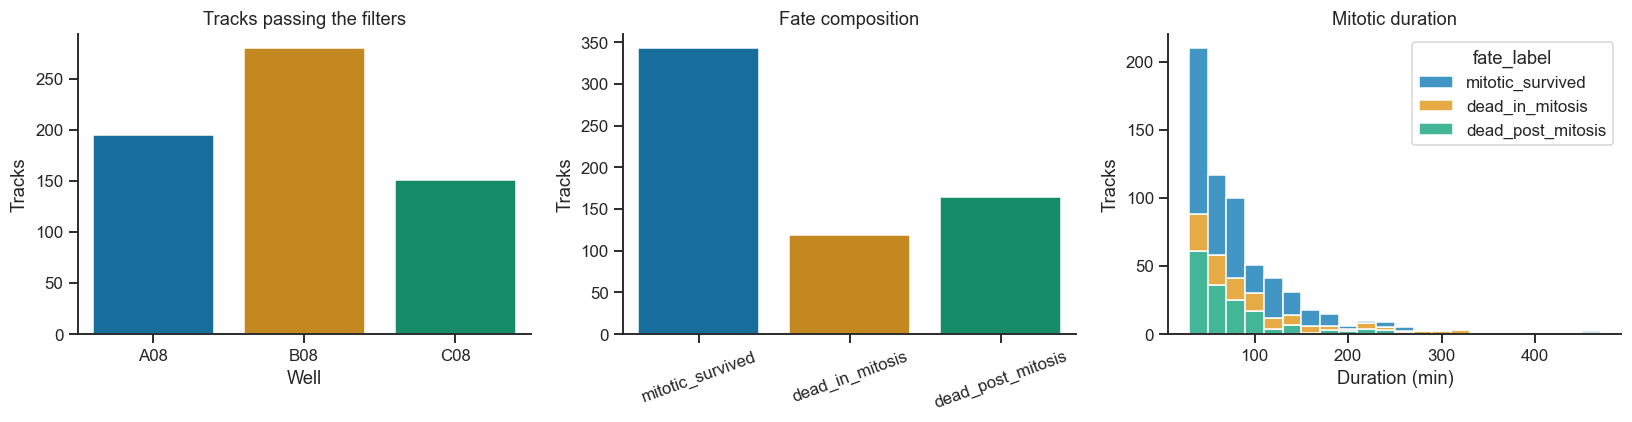

In [3]:
counts = (df.groupby(["well", "position"])
            .agg(n_tracks=("particle", "size"),
                 median_min=(DURATION, "median"))
            .reset_index())
display(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=counts, x="well", y="n_tracks", estimator="sum",
            errorbar=None, ax=axes[0], hue="well", legend=False)
axes[0].set(title="Tracks passing the filters", xlabel="Well", ylabel="Tracks")

sns.countplot(data=df, x="fate_label", order=FATE_ORDER, palette=FATE_PAL,
              hue="fate_label", legend=False, ax=axes[1])
axes[1].set(title="Fate composition", xlabel="", ylabel="Tracks")
axes[1].tick_params(axis="x", rotation=20)

sns.histplot(data=df, x=DURATION, hue="fate_label", hue_order=FATE_ORDER,
             palette=FATE_PAL, multiple="stack", binwidth=20, ax=axes[2])
axes[2].set(title="Mitotic duration", xlabel="Duration (min)", ylabel="Tracks")

sns.despine(fig)
fig.tight_layout()
save(fig, "01_plate_overview")

saved 02_duration_by_position.png / .pdf


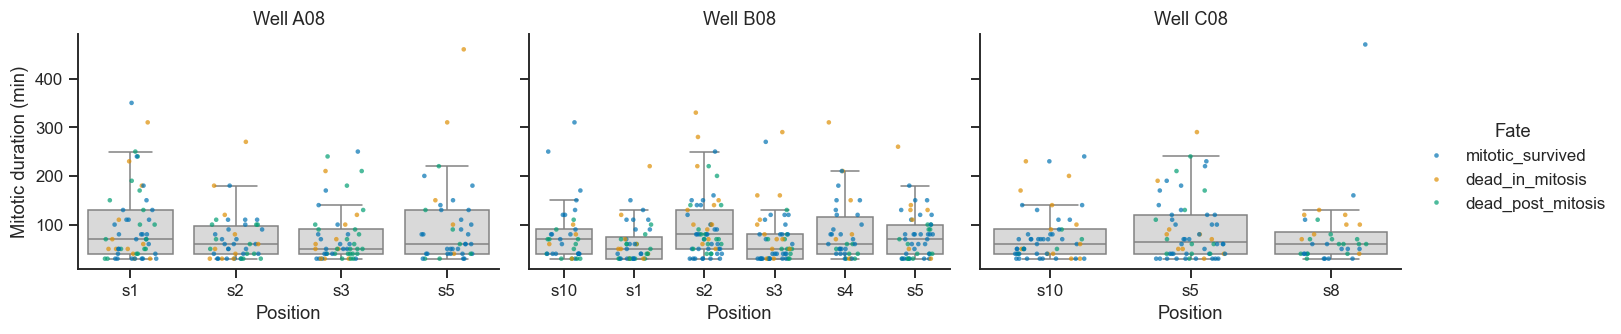

In [4]:
# Per-position consistency: a position whose median sits far off the others is
# usually a focus or seeding problem, not biology.
g = sns.catplot(data=df, x="position", y=DURATION, col="well", kind="box",
                col_wrap=3, height=3.2, aspect=1.35, sharex=False,
                color=".85", fliersize=0)
g.map_dataframe(sns.stripplot, x="position", y=DURATION, hue="fate_label",
                hue_order=FATE_ORDER, palette=FATE_PAL, size=3, alpha=.7,
                jitter=.25, dodge=False)
g.set_axis_labels("Position", "Mitotic duration (min)")
g.set_titles("Well {col_name}")
g.add_legend(title="Fate")
save(g, "02_duration_by_position")

## 3. Audit of the correction maps

The summaries do **not** store a corrected signal. They store three numbers per
channel, and the correction is applied downstream:

| column | meaning |
| --- | --- |
| `<ch>` | raw mean signal inside the cell mask |
| `<ch>_bkg_corr` | mean of the **background map** under that mask — to be **subtracted** |
| `<ch>_int_corr` | mean of the **intensity map** under that mask — to **divide** by |

$$\text{corrected} = \frac{\text{raw} - \text{bkg\_corr}}{\text{int\_corr}}$$

Two things have to hold for that to mean anything, and both are checked here:
that the right map file was used, and that the background level is actually
below the signal.

In [5]:
# --- 3a. which map files exist, and which one cellaap_analysis actually used ---
# _load_maps walks the root, matches `background|intensity` and a channel name
# anywhere in the file name, and OVERWRITES on each hit - so the last file the
# directory listing yields wins. Replay that here.
map_files = [f for f in os.listdir(ROOT) if re.search(r"background|intensity", f)]

rows, used = [], {}
for name in map_files:
    kind    = re.search(r"background|intensity", name).group()
    channel = re.search(r"GFP|Texas Red|Cy5|phs", name).group()
    source  = re.search(r"_([A-H]\d{2})_s(\d+)_", name)
    rows.append({"file": name, "channel": channel, "kind": kind,
                 "from_well": source.group(1) if source else "?"})
    used[(channel, kind)] = name          # last wins, exactly as _load_maps does

maps_df = pd.DataFrame(rows).sort_values(["channel", "kind", "from_well"])
print("Correction map files present in the root folder:\n")
display(maps_df.reset_index(drop=True))

# --- what the platemap says those wells are ---
platemap = agg.read_platemap(ROOT)
roles = {r.well_ids.strip(): str(r.role).strip().lower()
         for r in platemap.itertuples() if str(r.role).strip()}
ROLE_TO_KIND = {"fluorobrite": "background", "background": "background",
                "dmem": "intensity", "intensity": "intensity"}
print("Blank wells declared in the platemap:",
      {w: f"{r} -> {ROLE_TO_KIND.get(r, '?')} map" for w, r in roles.items()})

Correction map files present in the root folder:



,file,channel,kind,from_well
0,20250213_HT1080 pPS18_E08_s6_GFP_background_ma...,GFP,background,E08
1,20250213_HT1080 pPS18_D08_s8_GFP_intensity_map...,GFP,intensity,D08
2,20250213_HT1080 pPS18_E08_s6_GFP_intensity_map...,GFP,intensity,E08
3,20250213_HT1080 pPS18_D08_s8_Texas Red_backgro...,Texas Red,background,D08
4,20250213_HT1080 pPS18_E08_s6_Texas Red_backgro...,Texas Red,background,E08
5,20250213_HT1080 pPS18_D08_s8_Texas Red_intensi...,Texas Red,intensity,D08
6,20250213_HT1080 pPS18_E08_s6_Texas Red_intensi...,Texas Red,intensity,E08


Blank wells declared in the platemap: {'D08': 'dmem -> intensity map', 'E08': 'fluorobrite -> background map'}


In [6]:
# --- 3b. verdict per channel x correction ---
verdict = []
for (channel, kind), name in sorted(used.items()):
    same = maps_df[(maps_df.channel == channel) & (maps_df.kind == kind)]
    src  = re.search(r"_([A-H]\d{2})_s\d+_", name).group(1)
    declared = ROLE_TO_KIND.get(roles.get(src, ""), "not a blank well")
    verdict.append({
        "channel": channel, "correction": kind,
        "candidates": len(same),
        "used (last wins)": name,
        "from well": src,
        "platemap says that well is": declared,
        "ok": "yes" if (len(same) == 1 and declared == kind)
              else ("AMBIGUOUS" if len(same) > 1 and declared == kind
                    else "WRONG SOURCE"),
    })
verdict = pd.DataFrame(verdict)
display(verdict)

bad = verdict[verdict["ok"] != "yes"]
if len(bad):
    print(f"\n!! {len(bad)} of {len(verdict)} corrections are not unambiguous.")
    print("   `pipeline.py check --root <folder>` refuses to run in this state;")
    print("   these maps predate that check. Delete the stale files and re-run")
    print("   the affected positions with --force to fix it at the source.")

,channel,correction,candidates,used (last wins),from well,platemap says that well is,ok
0,GFP,background,1,20250213_HT1080 pPS18_E08_s6_GFP_background_ma...,E08,background,yes
1,GFP,intensity,2,20250213_HT1080 pPS18_D08_s8_GFP_intensity_map...,D08,intensity,AMBIGUOUS
2,Texas Red,background,2,20250213_HT1080 pPS18_D08_s8_Texas Red_backgro...,D08,intensity,WRONG SOURCE
3,Texas Red,intensity,2,20250213_HT1080 pPS18_D08_s8_Texas Red_intensi...,D08,intensity,AMBIGUOUS



!! 3 of 4 corrections are not unambiguous.
   `pipeline.py check --root <folder>` refuses to run in this state;
   these maps predate that check. Delete the stale files and re-run
   the affected positions with --force to fix it at the source.


,channel,raw median,background map median,bkg / raw,intensity map range,% cells raw > bkg,% negative after subtraction
0,GFP,182.95,514.84,2.81,0.80 - 0.99,0.00,100.00
1,Texas Red,201.95,303.18,1.50,0.76 - 1.00,6.87,93.13


saved 03_background_vs_signal.png / .pdf


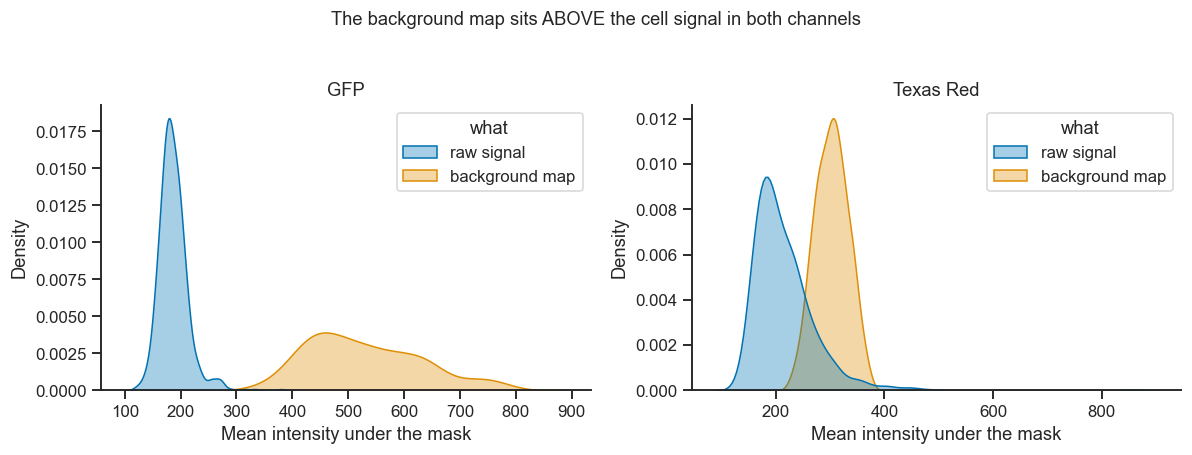

In [7]:
# --- 3c. is the background level even below the signal? ---
audit = []
for ch in CHANNELS:
    raw, bkg, itc = df[ch], df[f"{ch}_bkg_corr"], df[f"{ch}_int_corr"]
    audit.append({
        "channel": ch,
        "raw median": raw.median(),
        "background map median": bkg.median(),
        "bkg / raw": bkg.median() / raw.median(),
        "intensity map range": f"{itc.min():.2f} - {itc.max():.2f}",
        "% cells raw > bkg": 100 * (raw > bkg).mean(),
        "% negative after subtraction": 100 * ((raw - bkg) < 0).mean(),
    })
audit = pd.DataFrame(audit).round(2)
display(audit)

fig, axes = plt.subplots(1, len(CHANNELS), figsize=(11, 4))
for ax, ch in zip(np.atleast_1d(axes), CHANNELS):
    long = pd.concat([
        df[[ch]].rename(columns={ch: "value"}).assign(what="raw signal"),
        df[[f"{ch}_bkg_corr"]].rename(columns={f"{ch}_bkg_corr": "value"})
          .assign(what="background map"),
    ])
    sns.kdeplot(data=long, x="value", hue="what", fill=True, alpha=.35,
                common_norm=False, ax=ax)
    ax.set(title=ch, xlabel="Mean intensity under the mask", ylabel="Density")
sns.despine(fig)
fig.suptitle("The background map sits ABOVE the cell signal in both channels",
             y=1.03, fontsize=12)
fig.tight_layout()
save(fig, "03_background_vs_signal")

### What the audit says

Two separate problems, and the second is the one that matters for the plots below.

**Ambiguous / wrong map sources.** The platemap declares `D08` as `dmem`
(→ intensity map) and `E08` as `fluorobrite` (→ background map), so there should
be four map files. There are seven, including maps from wells whose declared
role does not produce them. Because `_load_maps` keeps whichever file the
directory listing yields last, the Texas Red *background* was taken from the
**DMEM** well rather than the fluorobrite well. This is exactly the
"two maps for one channel" failure that `pipeline.py check` now refuses to run
on; these files predate that check.

**The background level exceeds the signal.** This is the fatal one, and it is
not explained by the mix-up: GFP's background map came from the correct well and
is still ~2.8× the cell signal. Subtracting it drives **100% of GFP** and
**93% of Texas Red** measurements negative. A ratio like that is a mismatch in
acquisition (exposure/gain, or blank medium far brighter than the cells) rather
than a background in the usual sense.

**Consequence.** `(raw - bkg)/int` is not usable on this plate as stored. So
below, four signal variants are carried side by side rather than one:

| variant | formula | |
| --- | --- | --- |
| `raw` | `raw` | no correction |
| `int only` | `raw / int_corr` | spatial correction alone — this one is well behaved |
| `map bkg + int` | `(raw - bkg_corr) / int_corr` | as designed; shown so the failure is visible |
| `emp bkg + int` | `(raw - q₂ per position) / int_corr` | empirical offset, the usable stand-in |

The empirical offset is the 2nd percentile of the raw signal **within each
position**, which is the rough background subtraction `fit_model` recommends
when blank-well data are unavailable. Per position, not plate-wide, so it also
absorbs field-to-field offset drift.

In [8]:
OFFSET_Q = 0.02
STAGES = ["raw", "int only", "map bkg + int", "emp bkg + int"]

def add_variants(frame):
    frame = frame.copy()
    for ch in CHANNELS:
        raw = frame[ch]
        bkg = frame[f"{ch}_bkg_corr"]
        itc = frame[f"{ch}_int_corr"]
        emp = frame.groupby("stem")[ch].transform(lambda s: s.quantile(OFFSET_Q))
        frame[f"{ch}|raw"]           = raw
        frame[f"{ch}|int only"]      = raw / itc
        frame[f"{ch}|map bkg + int"] = (raw - bkg) / itc
        frame[f"{ch}|emp bkg + int"] = (raw - emp) / itc
    return frame

df = add_variants(df)

# Long form: one row per (track, channel, correction stage).
value_cols = [f"{ch}|{s}" for ch in CHANNELS for s in STAGES]
keep = ["stem", "well", "position", "particle", "fate_label", DURATION,
        "track_length", "mitotic_start_frame"]
tidy = (df[keep + value_cols]
        .melt(id_vars=keep, value_vars=value_cols,
              var_name="channel_stage", value_name="signal"))
tidy[["channel", "stage"]] = tidy["channel_stage"].str.split("|", expand=True)
tidy = tidy.drop(columns="channel_stage")
tidy["stage"] = pd.Categorical(tidy["stage"], categories=STAGES, ordered=True)

print(f"tidy: {tidy.shape[0]} rows = {len(df)} tracks x {len(CHANNELS)} channels "
      f"x {len(STAGES)} stages")
display(tidy.groupby(["channel", "stage"], observed=True)["signal"]
            .agg(["median", "min", "max"]).round(1))

tidy: 5008 rows = 626 tracks x 2 channels x 4 stages


median    min    max
channel   stage                              
GFP       raw             183.0  119.4  379.6
          int only        199.6  132.1  411.8
          map bkg + int  -357.9 -662.9  -43.5
          emp bkg + int    36.7  -15.7  255.8
Texas Red raw             202.0  134.8  856.8
          int only        221.5  155.6  924.5
          map bkg + int  -103.6 -191.2  597.7
          emp bkg + int    52.0  -27.1  756.4

## 4. Mitotic duration vs signal

The question is whether a cell's GFP or Texas Red level predicts how long it
spends in mitosis. Three views: the raw cloud, a binned trend that is readable
through the scatter, and a correlation summary.

saved 04_duration_vs_signal_scatter.png / .pdf


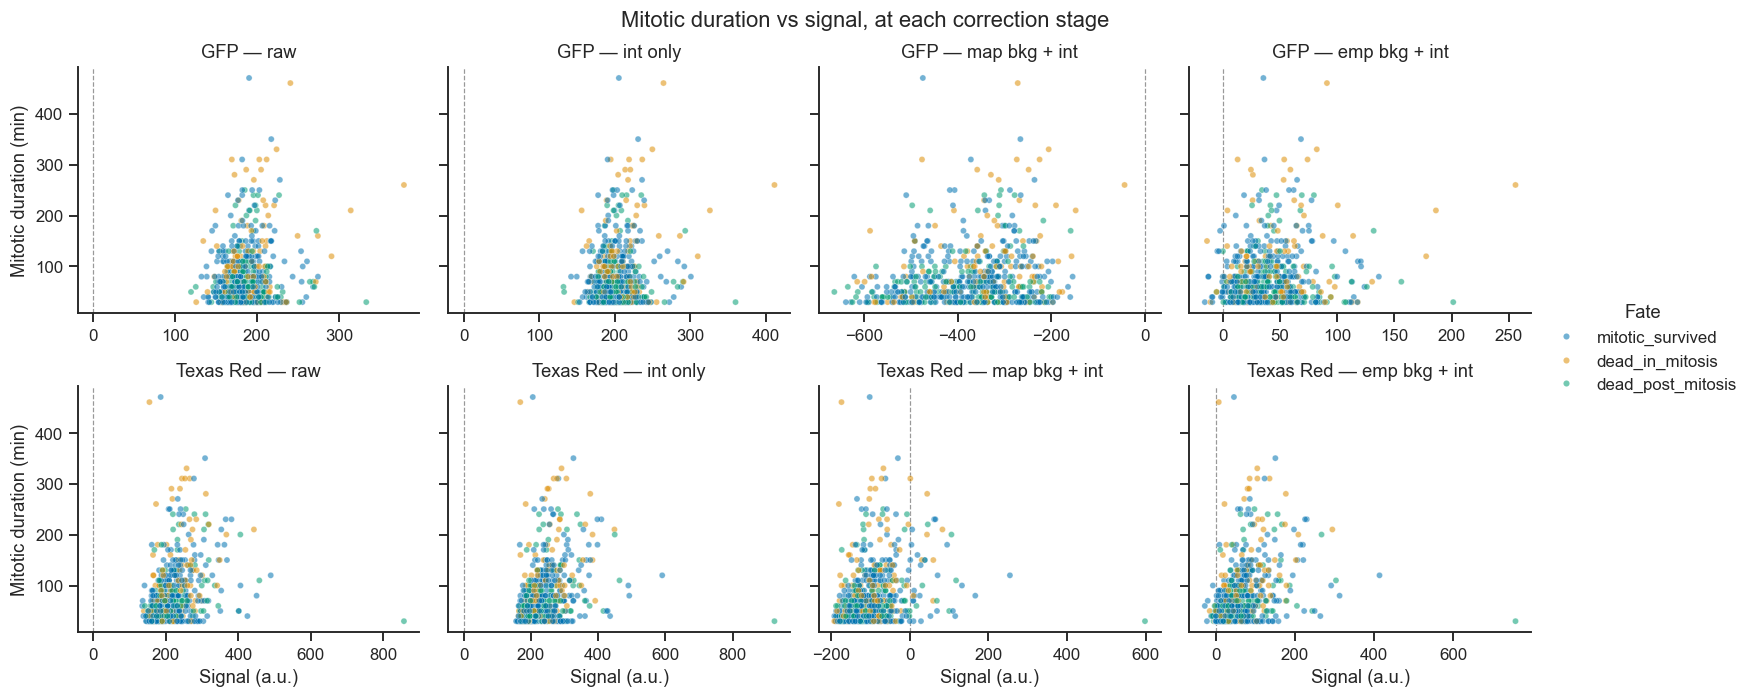

In [9]:
g = sns.relplot(data=tidy, x="signal", y=DURATION,
                col="stage", row="channel", kind="scatter",
                hue="fate_label", hue_order=FATE_ORDER, palette=FATE_PAL,
                height=3.1, aspect=1.15, s=16, alpha=.55,
                facet_kws=dict(sharex=False, sharey=True))
g.set_axis_labels("Signal (a.u.)", "Mitotic duration (min)")
g.set_titles("{row_name} — {col_name}")
g._legend.set_title("Fate")
for ax in g.axes.flat:
    ax.axvline(0, color="0.6", lw=.8, ls="--", zorder=0)
g.figure.suptitle("Mitotic duration vs signal, at each correction stage", y=1.02)
save(g, "04_duration_vs_signal_scatter")

saved 05_duration_vs_signal_binned.png / .pdf


stage                   raw  int only  map bkg + int  emp bkg + int
channel   signal_bin                                               
GFP       0            60.0      60.0           40.0           60.0
          1            50.0      60.0           70.0           60.0
          2            60.0      60.0           60.0           60.0
          3            60.0      60.0           60.0           60.0
          4            60.0      70.0           75.0           70.0
          5            70.0      60.0           70.0           70.0
          6            50.0      70.0           65.0           60.0
          7            70.0      60.0           70.0           70.0
Texas Red 0            40.0      40.0           40.0           40.0
          1            40.0      45.0           50.0           40.0
          2            50.0      60.0           60.0           50.0
          3            70.0      60.0           60.0           70.0
          4            80.0      75.0           80.0           80.0
          5            80.0      90.0           70.0           80.0
          6            90.0      80.0           80.0           90.0
          7           110.0     100.0           90.0          110.0

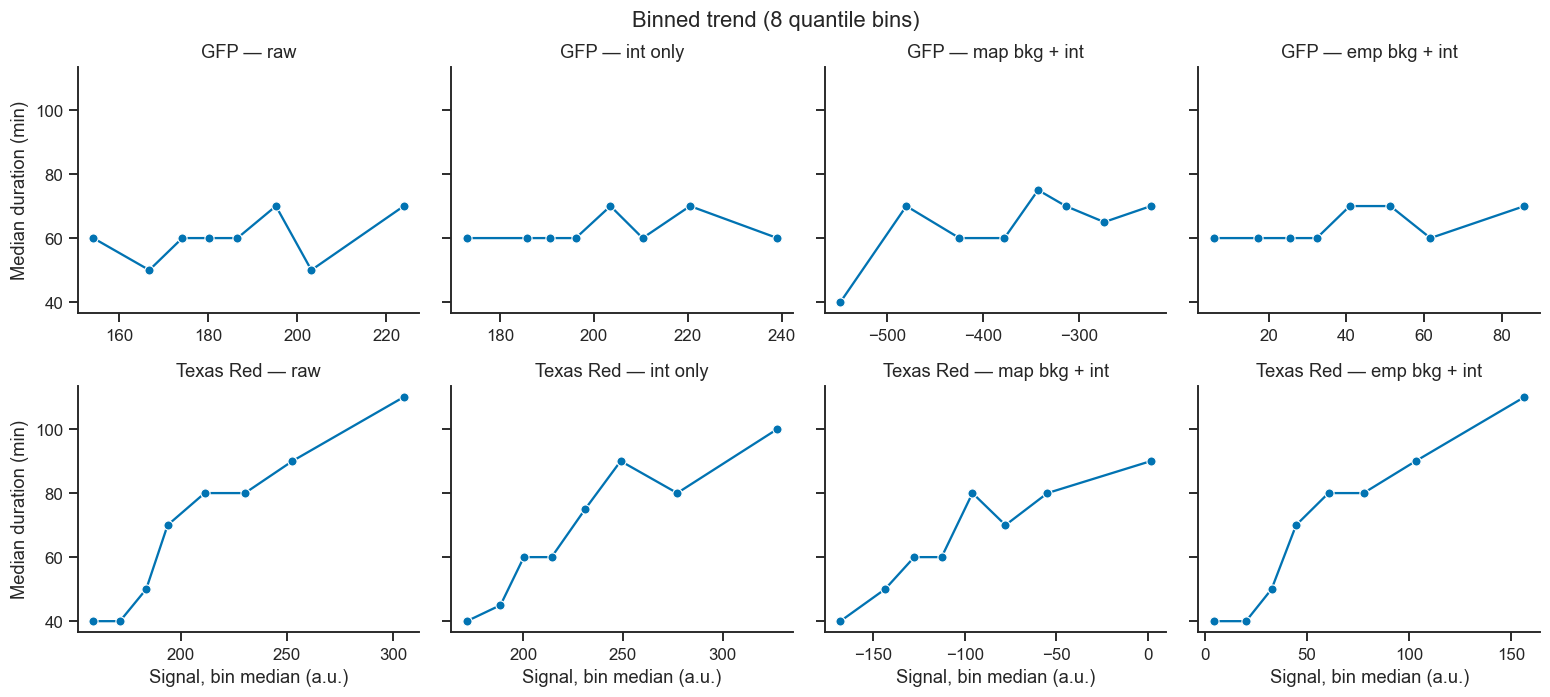

In [10]:
# Binned trend: quantile bins of the signal within each channel x stage, then the
# median duration per bin with a bootstrapped CI. Quantile bins keep every bin
# populated despite the heavy right tail of the fluorescence distribution.
N_BINS = 8

def qbin(s):
    try:
        return pd.qcut(s, N_BINS, labels=False, duplicates="drop")
    except ValueError:
        return pd.Series(np.nan, index=s.index)

tidy["signal_bin"] = (tidy.groupby(["channel", "stage"], observed=True)["signal"]
                          .transform(qbin))
binned = (tidy.dropna(subset=["signal_bin"])
              .groupby(["channel", "stage", "signal_bin"], observed=True)
              .agg(signal=("signal", "median"),
                   duration=(DURATION, "median"),
                   n=(DURATION, "size"))
              .reset_index())

g = sns.relplot(data=binned, x="signal", y="duration", col="stage", row="channel",
                kind="line", marker="o", height=3.1, aspect=1.15,
                facet_kws=dict(sharex=False, sharey=True))
g.set_axis_labels("Signal, bin median (a.u.)", "Median duration (min)")
g.set_titles("{row_name} — {col_name}")
g.figure.suptitle(f"Binned trend ({N_BINS} quantile bins)", y=1.02)
save(g, "05_duration_vs_signal_binned")

display(binned.pivot_table(index=["channel", "signal_bin"], columns="stage",
                           values="duration", observed=True).round(0))

,channel,stage,rho,p,n,rho_within_median,n_positions
0,GFP,raw,0.091,0.023,626,0.084,13
1,GFP,int only,0.068,0.090,626,0.060,13
2,GFP,map bkg + int,0.160,0.000,626,0.154,13
3,GFP,emp bkg + int,0.071,0.076,626,0.110,13
4,Texas Red,raw,0.452,0.000,626,0.528,13
5,Texas Red,int only,0.438,0.000,626,0.467,13
6,Texas Red,map bkg + int,0.324,0.000,626,0.331,13
7,Texas Red,emp bkg + int,0.460,0.000,626,0.521,13


saved 06_spearman_heatmap.png / .pdf


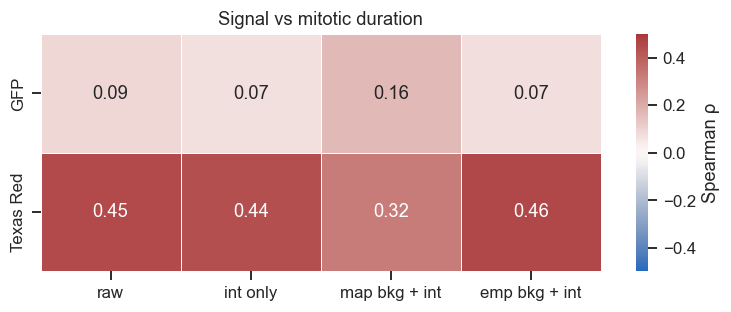

In [11]:
# Spearman (monotonic, outlier-tolerant) between signal and duration.
# The three corrections are strictly monotonic per position, so within a single
# position they cannot change the ranking - any change here comes from how the
# corrections re-scale positions RELATIVE to each other.
corr_rows = []
for (ch, stage), grp in tidy.groupby(["channel", "stage"], observed=True):
    ok = grp[["signal", DURATION]].dropna()
    rho, p = stats.spearmanr(ok["signal"], ok[DURATION])
    corr_rows.append({"channel": ch, "stage": stage, "rho": rho, "p": p, "n": len(ok)})

    # ...and the same thing pooled WITHIN position, which removes between-field
    # offset entirely and is the fairer test of a per-cell relationship.
within = []
for (ch, stage), grp in tidy.groupby(["channel", "stage"], observed=True):
    rhos = []
    for _, sub in grp.groupby("stem"):
        ok = sub[["signal", DURATION]].dropna()
        if len(ok) > 8:
            rhos.append(stats.spearmanr(ok["signal"], ok[DURATION]).statistic)
    within.append({"channel": ch, "stage": stage, "rho_within_median": np.median(rhos),
                   "n_positions": len(rhos)})

corr_df = pd.DataFrame(corr_rows).merge(pd.DataFrame(within), on=["channel", "stage"])
display(corr_df.round(3))

fig, ax = plt.subplots(figsize=(7, 3))
piv = corr_df.pivot(index="channel", columns="stage", values="rho")[STAGES]
sns.heatmap(piv, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-.5, vmax=.5, linewidths=.5, ax=ax,
            cbar_kws={"label": "Spearman ρ"})
ax.set(title="Signal vs mitotic duration", xlabel="", ylabel="")
fig.tight_layout()
save(fig, "06_spearman_heatmap")

### 4b. Dose–response fit

Texas Red behaves like a dosage and mitotic duration like the response, which is
exactly the shape `fit_model` was written for: a 4-parameter Hill sigmoid over
quantile-binned data. It needs a positive, background-subtracted dose, so it is
run on the empirically corrected signal.

/Users/ajitjoglekar/Library/CloudStorage/GoogleDrive-ajitj@umich.edu/My Drive/ImageAnalysis/cellapp-analysis/cellaap_aggregate.py:675: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = xy_data.groupby("bins").mean()
/Users/ajitjoglekar/Library/CloudStorage/GoogleDrive-ajitj@umich.edu/My Drive/ImageAnalysis/cellapp-analysis/cellaap_aggregate.py:676: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_sizes = xy_data.groupby("bins").size()
/Users/ajitjoglekar/Library/CloudStorage/GoogleDrive-ajitj@umich.edu/My Drive/ImageAnalysis/cellapp-analysis/cellaap_aggregate.py:677: FutureWarning: The default of obs

saved 14_hill_fit_GFP.png / .pdf
GFP: EC50 = 144968.2, Hill n = 1.15, min = 64 min, max = 225439 min
   -> DEGENERATE: EC50 and/or plateau lie far outside the data (dose max 256, duration max 470 min).
      There is no dose-response to fit in this channel; ignore these parameters.


/Users/ajitjoglekar/Library/CloudStorage/GoogleDrive-ajitj@umich.edu/My Drive/ImageAnalysis/cellapp-analysis/cellaap_aggregate.py:675: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = xy_data.groupby("bins").mean()
/Users/ajitjoglekar/Library/CloudStorage/GoogleDrive-ajitj@umich.edu/My Drive/ImageAnalysis/cellapp-analysis/cellaap_aggregate.py:676: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_sizes = xy_data.groupby("bins").size()
/Users/ajitjoglekar/Library/CloudStorage/GoogleDrive-ajitj@umich.edu/My Drive/ImageAnalysis/cellapp-analysis/cellaap_aggregate.py:677: FutureWarning: The default of obs

saved 14_hill_fit_Texas_Red.png / .pdf
Texas Red: EC50 = 90.8, Hill n = 1.62, min = 48 min, max = 152 min
   -> within the measured range (dose max 756, duration max 470 min): usable

channels with a usable Hill fit: ['Texas Red']


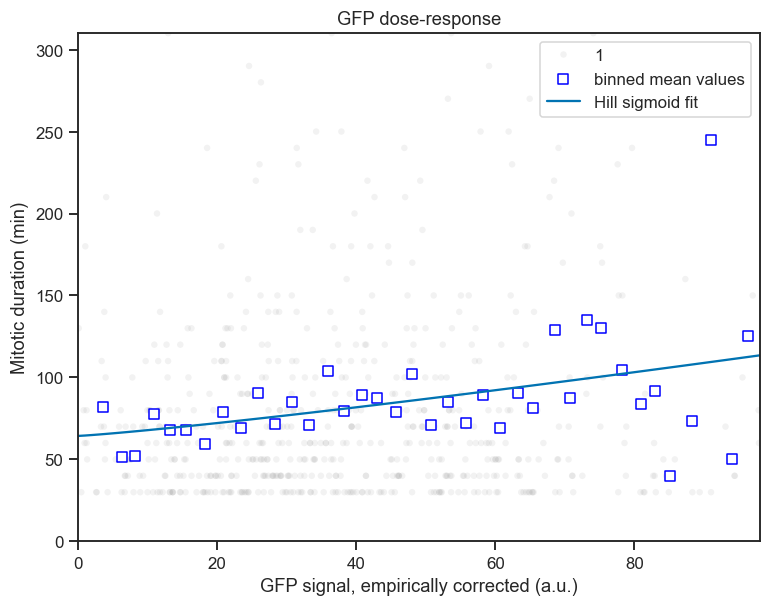

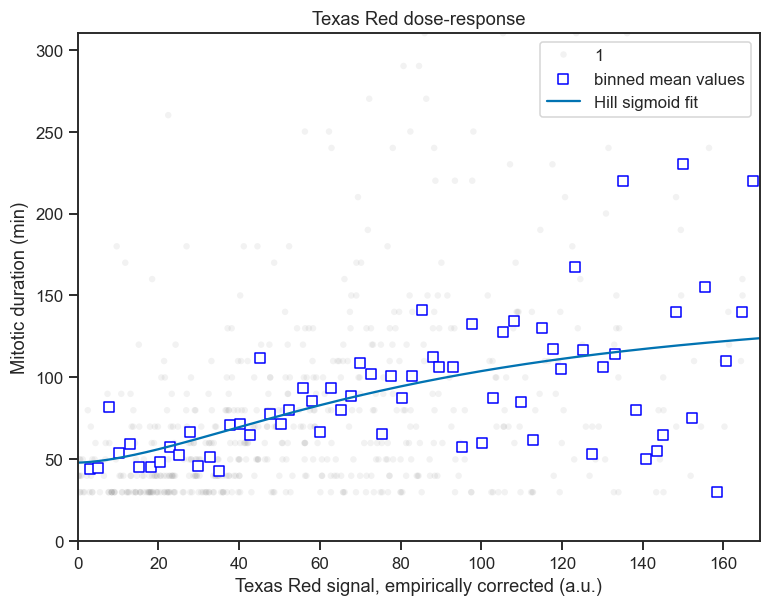

In [12]:
fits = {}
for ch in CHANNELS:
    dose_response = (df[[f"{ch}|emp bkg + int", DURATION]]
                     .rename(columns={f"{ch}|emp bkg + int": "dose",
                                      DURATION: "response"})
                     .replace([np.inf, -np.inf], np.nan).dropna())
    dose_response = dose_response[dose_response["dose"] > 0]
    try:
        xy, means, errs, sizes, pars = agg.fit_model(
            dose_response.copy(), plot=True, quant_fraction=[0.025, 0.85])
        ax = plt.gca()
        ax.set(xlabel=f"{ch} signal, empirically corrected (a.u.)",
               ylabel="Mitotic duration (min)", title=f"{ch} dose-response")
        save(plt.gcf(), f"14_hill_fit_{ch.replace(' ', '_')}")

        # curve_fit always returns something. Without a real sigmoid it walks
        # off to an EC50 far outside the measured dose range and an asymptote
        # far above any observed duration - report that as "no dose-response"
        # rather than as parameters.
        dose_max, dur_max = dose_response["dose"].max(), dose_response["response"].max()
        plausible = (0 < pars["EC50"] < dose_max) and (pars["max_duration"] < 3 * dur_max)
        print(f"{ch}: EC50 = {pars['EC50']:.1f}, Hill n = {pars['Hill_exponent']:.2f}, "
              f"min = {pars['min_duration']:.0f} min, max = {pars['max_duration']:.0f} min")
        if plausible:
            fits[ch] = pars
            print(f"   -> within the measured range (dose max {dose_max:.0f}, "
                  f"duration max {dur_max:.0f} min): usable")
        else:
            print(f"   -> DEGENERATE: EC50 and/or plateau lie far outside the data "
                  f"(dose max {dose_max:.0f}, duration max {dur_max:.0f} min).")
            print(f"      There is no dose-response to fit in this channel; "
                  f"ignore these parameters.")
    except Exception as exc:
        print(f"{ch}: fit did not converge ({type(exc).__name__}: {exc})")

print("\nchannels with a usable Hill fit:", list(fits) or "none")

## 5. Mitotic duration and signal vs cell fate

saved 07_duration_by_fate.png / .pdf
Kruskal-Wallis across the three fates: H = 13.2, p = 1.37e-03

  mitotic_survived   (med    60) vs dead_in_mitosis    (med    80): p = 2.61e-03, rank-biserial r = +0.18
  mitotic_survived   (med    60) vs dead_post_mitosis  (med    60): p = 2.84e-01, rank-biserial r = -0.06
  dead_in_mitosis    (med    80) vs dead_post_mitosis  (med    60): p = 4.62e-04, rank-biserial r = -0.24


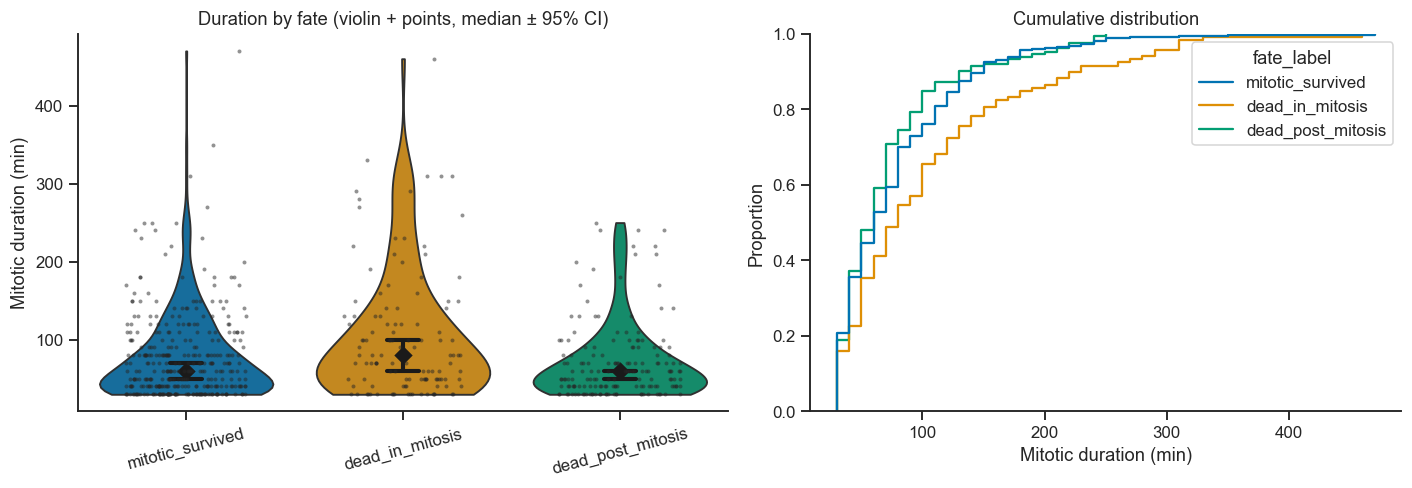

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6),
                         gridspec_kw={"width_ratios": [1.1, 1]})

sns.violinplot(data=df, x="fate_label", y=DURATION, order=FATE_ORDER,
               hue="fate_label", palette=FATE_PAL, legend=False,
               inner=None, cut=0, ax=axes[0])
sns.stripplot(data=df, x="fate_label", y=DURATION, order=FATE_ORDER,
              color="0.15", size=2.6, alpha=.5, jitter=.28, ax=axes[0])
sns.pointplot(data=df, x="fate_label", y=DURATION, order=FATE_ORDER,
              estimator="median", errorbar=("ci", 95), color="k",
              markers="D", linestyle="none", capsize=.15, ax=axes[0])
axes[0].set(xlabel="", ylabel="Mitotic duration (min)",
            title="Duration by fate (violin + points, median ± 95% CI)")
axes[0].tick_params(axis="x", rotation=15)

sns.ecdfplot(data=df, x=DURATION, hue="fate_label", hue_order=FATE_ORDER,
             palette=FATE_PAL, ax=axes[1])
axes[1].set(xlabel="Mitotic duration (min)", ylabel="Proportion",
            title="Cumulative distribution")

sns.despine(fig)
fig.tight_layout()
save(fig, "07_duration_by_fate")

# Non-parametric test across the three fates, plus pairwise.
groups = [g[DURATION].values for _, g in df.groupby("fate_label")]
H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis across the three fates: H = {H:.1f}, p = {p:.2e}\n")
for a, b in [("mitotic_survived", "dead_in_mitosis"),
             ("mitotic_survived", "dead_post_mitosis"),
             ("dead_in_mitosis",  "dead_post_mitosis")]:
    x, y = df.loc[df.fate_label == a, DURATION], df.loc[df.fate_label == b, DURATION]
    u, pu = stats.mannwhitneyu(x, y)
    # rank-biserial effect size
    r = 1 - 2 * u / (len(x) * len(y))
    print(f"  {a:18s} (med {x.median():5.0f}) vs {b:18s} (med {y.median():5.0f}): "
          f"p = {pu:.2e}, rank-biserial r = {r:+.2f}")

saved 08_signal_by_fate.png / .pdf
Kruskal-Wallis, signal across fates:

  GFP        raw              H =    7.1  p = 2.94e-02
  GFP        int only         H =    6.7  p = 3.56e-02
  GFP        map bkg + int    H =   11.0  p = 4.07e-03
  GFP        emp bkg + int    H =    7.2  p = 2.73e-02
  Texas Red  raw              H =    2.2  p = 3.28e-01
  Texas Red  int only         H =    4.5  p = 1.04e-01
  Texas Red  map bkg + int    H =    1.3  p = 5.29e-01
  Texas Red  emp bkg + int    H =    2.1  p = 3.41e-01


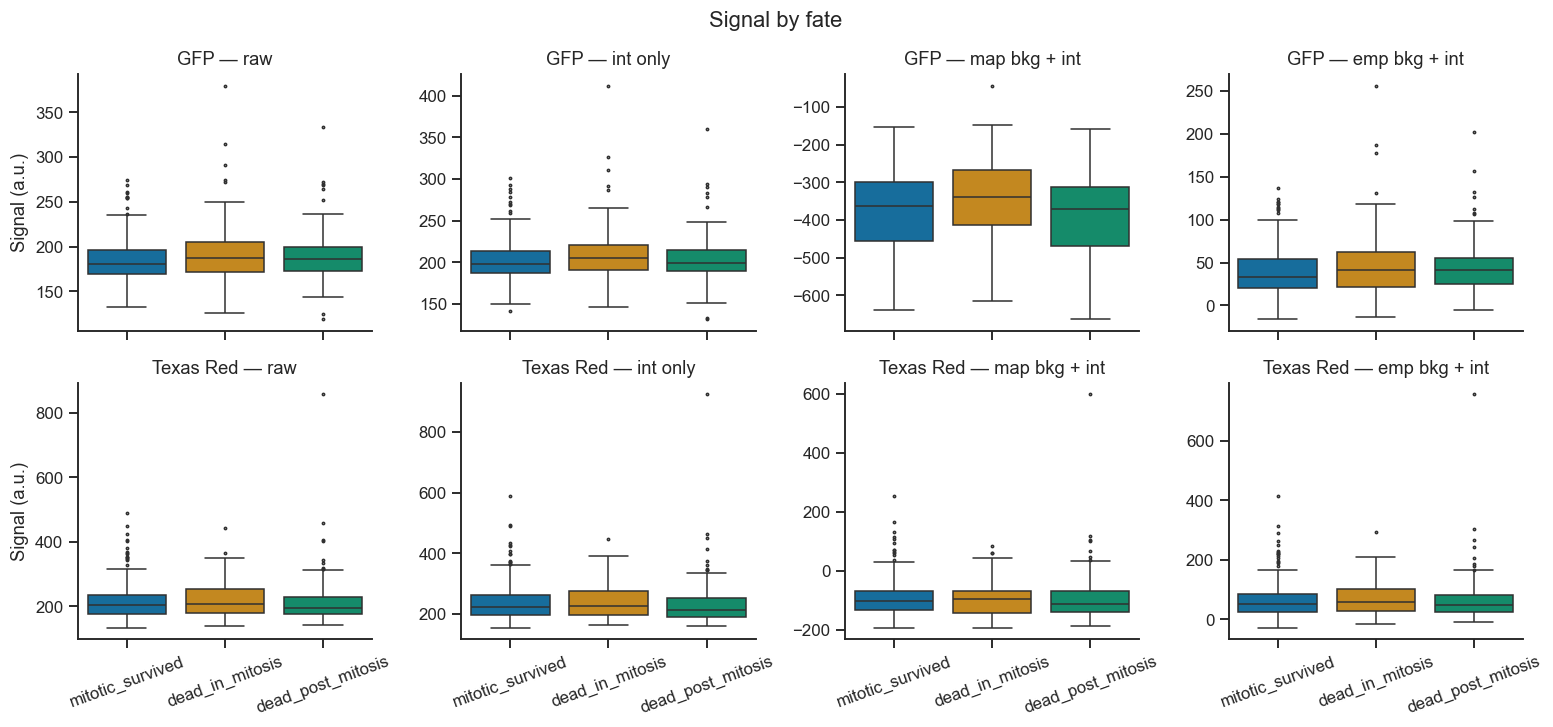

In [14]:
# Does the signal itself differ by fate? Shown at every correction stage, since
# a difference that only appears after a broken correction is an artifact.
g = sns.catplot(data=tidy, x="fate_label", y="signal", col="stage", row="channel",
                kind="box", order=FATE_ORDER, hue="fate_label",
                hue_order=FATE_ORDER, palette=FATE_PAL, legend=False,
                height=3.1, aspect=1.15, fliersize=1.5,
                sharey=False)
g.set_axis_labels("", "Signal (a.u.)")
g.set_titles("{row_name} — {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
g.figure.suptitle("Signal by fate", y=1.03)
save(g, "08_signal_by_fate")

print("Kruskal-Wallis, signal across fates:\n")
for (ch, stage), grp in tidy.groupby(["channel", "stage"], observed=True):
    gs = [g["signal"].dropna().values for _, g in grp.groupby("fate_label")]
    H, p = stats.kruskal(*gs)
    print(f"  {ch:10s} {stage:16s} H = {H:6.1f}  p = {p:.2e}")

saved 09_duration_vs_signal_by_fate.png / .pdf


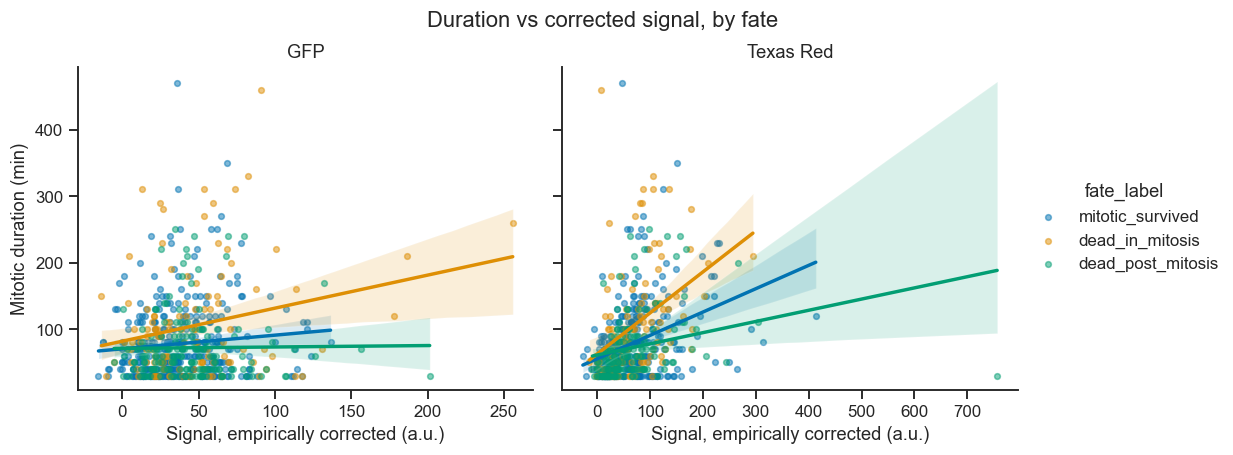

In [15]:
# Duration vs signal, split by fate - the two questions together.
g = sns.lmplot(data=tidy[tidy["stage"] == "emp bkg + int"],
               x="signal", y=DURATION, col="channel", hue="fate_label",
               hue_order=FATE_ORDER, palette=FATE_PAL,
               height=4, aspect=1.2, scatter_kws=dict(s=14, alpha=.5),
               facet_kws=dict(sharex=False), ci=95, robust=False)
g.set_axis_labels("Signal, empirically corrected (a.u.)", "Mitotic duration (min)")
g.set_titles("{col_name}")
g.figure.suptitle("Duration vs corrected signal, by fate", y=1.03)
save(g, "09_duration_vs_signal_by_fate")

## 6. How effective are the corrections?

Three tests, from weakest to strongest:

1. **Does the correction change the signal↔duration relationship?** — the plot
   the question asks for, before and after.
2. **Does it reduce between-position spread?** Both corrections should make
   fields more comparable; that is most of the point.
3. **Does the intensity correction actually flatten the spatial gradient?** This
   is the direct test — it uses the per-cell centroids in the `*_analysis.xlsx`
   files, so it is the slow cell, and it is cached.

saved 10_before_after_correction.png / .pdf


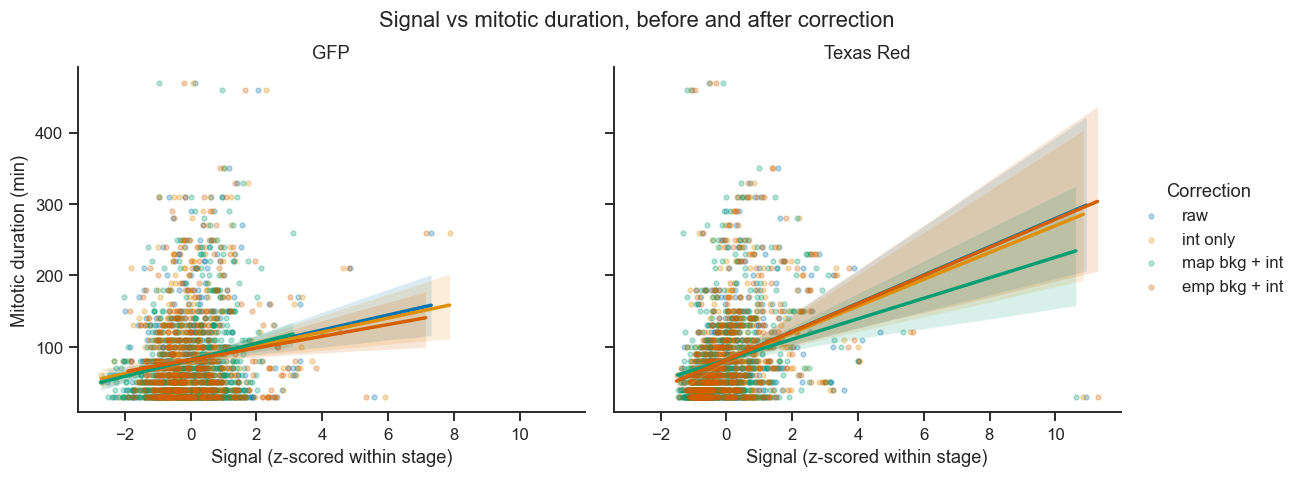

In [16]:
# --- 6.1 signal vs mitotic duration, before and after -----------------------
# Signals are z-scored within channel x stage so all four stages share an x axis;
# without that the map-corrected panel (negative, different scale) is unreadable
# next to the raw one.
tidy["signal_z"] = (tidy.groupby(["channel", "stage"], observed=True)["signal"]
                        .transform(lambda s: (s - s.mean()) / s.std()))

g = sns.lmplot(data=tidy, x="signal_z", y=DURATION, col="channel", hue="stage",
               hue_order=STAGES, height=4.2, aspect=1.25,
               scatter_kws=dict(s=10, alpha=.28), ci=95,
               facet_kws=dict(sharex=True))
g.set_axis_labels("Signal (z-scored within stage)", "Mitotic duration (min)")
g.set_titles("{col_name}")
g._legend.set_title("Correction")
g.figure.suptitle("Signal vs mitotic duration, before and after correction", y=1.03)
save(g, "10_before_after_correction")

,channel,stage,mean,sd,CV %,reliable
0,GFP,raw,183.82,6.01,3.27,yes
1,GFP,int only,199.61,7.15,3.58,yes
2,GFP,map bkg + int,-357.03,24.73,6.93,yes
3,GFP,emp bkg + int,38.88,15.35,39.47,no - mean near zero
4,Texas Red,raw,201.91,21.35,10.57,yes
5,Texas Red,int only,221.79,22.73,10.25,yes
6,Texas Red,map bkg + int,-105.53,22.16,21.00,yes
7,Texas Red,emp bkg + int,52.09,15.84,30.41,yes


saved 11_between_position_spread.png / .pdf


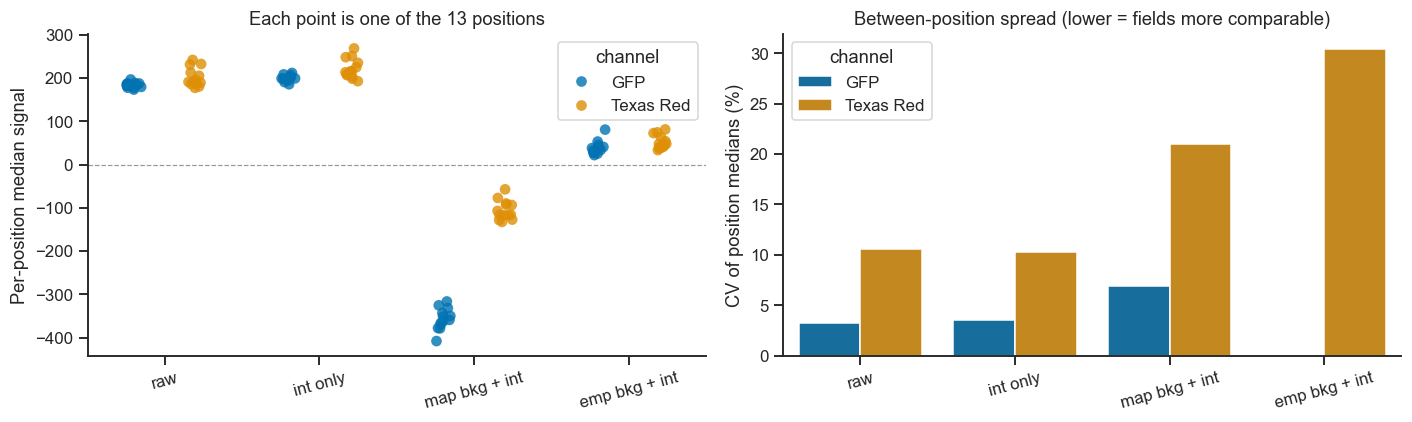

In [17]:
# --- 6.2 between-position spread -------------------------------------------
# If a correction works, the per-position medians should converge. Compared on
# the coefficient of variation of those medians, which is scale-free - except
# that it is meaningless when the mean sits near zero, which is precisely what
# the map-based stage does, so that stage is reported but flagged.
pos_med = (tidy.groupby(["channel", "stage", "stem"], observed=True)["signal"]
               .median().reset_index())
spread = (pos_med.groupby(["channel", "stage"], observed=True)["signal"]
                 .agg(mean="mean", sd="std").reset_index())
spread["CV %"] = 100 * spread["sd"] / spread["mean"].abs()
spread["reliable"] = np.where(spread["mean"].abs() > 3 * spread["sd"], "yes",
                              "no - mean near zero")
display(spread.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.stripplot(data=pos_med, x="stage", y="signal", hue="channel",
              dodge=True, size=7, alpha=.8, ax=axes[0])
axes[0].axhline(0, color="0.6", lw=.8, ls="--")
axes[0].set(xlabel="", ylabel="Per-position median signal",
            title="Each point is one of the 13 positions")
axes[0].tick_params(axis="x", rotation=15)

ok = spread[spread["reliable"] == "yes"]
sns.barplot(data=ok, x="stage", y="CV %", hue="channel", ax=axes[1])
axes[1].set(xlabel="", ylabel="CV of position medians (%)",
            title="Between-position spread (lower = fields more comparable)")
axes[1].tick_params(axis="x", rotation=15)
sns.despine(fig)
fig.tight_layout()
save(fig, "11_between_position_spread")

In [18]:
# --- 6.3 the direct test: does the intensity map flatten the field? ---------
# Reads the per-frame *_analysis.xlsx files, which carry the cell centroids that
# the summaries do not. ~580k rows over a network share: slow once, then cached.
CACHE_CELLS = CACHE / "cell_data.parquet"
WANT = ["frame", "x", "y", "particle"] + \
       [c for ch in CHANNELS for c in (ch, f"{ch}_int_corr", f"{ch}_bkg_corr")]

if CACHE_CELLS.exists():
    cells = pd.read_parquet(CACHE_CELLS)
    print(f"loaded {len(cells):,} rows from cache")
else:
    frames = []
    for pos in agg.platemap_positions(ROOT, verbose=False):
        hits = sorted(pos.inference_dir.glob("*_analysis.xlsx"))
        if not hits:
            print(f"  ! {pos.stub}: no analysis file"); continue
        d = pd.read_excel(hits[0], sheet_name="cell_data")
        d = d[[c for c in WANT if c in d.columns]].copy()
        d["stem"], d["well"], d["position"] = pos.stem, pos.well, pos.position
        frames.append(d)
        print(f"  {pos.stub}: {len(d):,} rows")
    cells = pd.concat(frames, ignore_index=True)
    cells.to_parquet(CACHE_CELLS)
    print(f"\ncached {len(cells):,} rows -> {CACHE_CELLS.name}")

# Radial distance from the field centre, normalized so it does not matter
# whether the centroids are in mask or image pixels.
span = cells[["x", "y"]].max()
cells["r"] = np.hypot(cells["x"] / span["x"] - .5, cells["y"] / span["y"] - .5) / .707
print(f"\ncentroid extent: x 0-{span['x']:.0f}, y 0-{span['y']:.0f}; "
      f"r in [{cells['r'].min():.2f}, {cells['r'].max():.2f}]")

loaded 430,746 rows from cache

centroid extent: x 0-1019, y 0-1017; r in [0.00, 0.99]


saved 12_radial_flatness.png / .pdf


,channel,stage,spread_pct,edge_over_centre
0,GFP,int only,1.897,1.000
1,GFP,raw,11.775,0.887
2,Texas Red,int only,11.793,1.107
3,Texas Red,raw,12.412,0.876


GFP       : edge/centre 0.887 -> 1.000   FLATTENS the field - correction working
Texas Red : edge/centre 0.876 -> 1.107   OVER-CORRECTS - gradient sign flipped


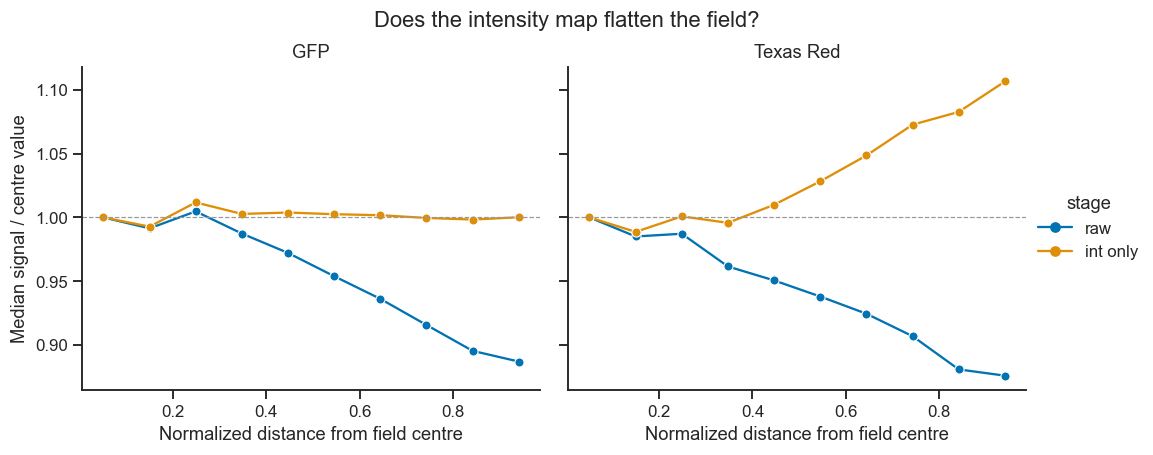

In [19]:
# Signal vs radial position, raw and intensity-corrected, each normalized to its
# own centre value so the two curves are directly comparable.
R_BINS = 10
cells["r_bin"] = pd.cut(cells["r"], R_BINS)
cells["r_mid"] = cells["r_bin"].map(lambda i: i.mid).astype(float)

radial = []
for ch in CHANNELS:
    for stage, vals in [("raw", cells[ch]),
                        ("int only", cells[ch] / cells[f"{ch}_int_corr"])]:
        tmp = pd.DataFrame({"r_mid": cells["r_mid"], "v": vals}).dropna()
        m = tmp.groupby("r_mid")["v"].median()
        radial.append(pd.DataFrame({"r_mid": m.index,
                                    "relative signal": m.values / m.iloc[0],
                                    "channel": ch, "stage": stage}))
radial = pd.concat(radial, ignore_index=True)

g = sns.relplot(data=radial, x="r_mid", y="relative signal", col="channel",
                hue="stage", kind="line", marker="o", height=4, aspect=1.2)
g.set_axis_labels("Normalized distance from field centre", "Median signal / centre value")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.axhline(1.0, color="0.6", lw=.8, ls="--")
g.figure.suptitle("Does the intensity map flatten the field?", y=1.03)
save(g, "12_radial_flatness")

# Quantify: total spread across radial bins, and centre-to-edge ratio.
summary = (radial.groupby(["channel", "stage"], observed=True)["relative signal"]
                 .agg(spread_pct=lambda s: 100 * (s.max() - s.min()),
                      edge_over_centre=lambda s: s.iloc[-1] / s.iloc[0])
                 .reset_index().round(3))
display(summary)
# Judge on the SIGNED edge/centre ratio, not on max-minus-min: a correction that
# turns a 12% falloff into a 12% rise leaves the spread unchanged while being
# badly wrong, and only the sign distinguishes the two.
for ch in CHANNELS:
    sub = summary[summary.channel == ch].set_index("stage")
    a, b = sub.loc["raw", "edge_over_centre"], sub.loc["int only", "edge_over_centre"]
    dev_a, dev_b = abs(a - 1), abs(b - 1)
    # Sign first: a flipped gradient is an over-correction however small the
    # residual magnitude, and must not be reported as partial success.
    if (b - 1) * (a - 1) < 0 and dev_b > 0.3 * dev_a:
        word = "OVER-CORRECTS - gradient sign flipped"
    elif dev_b < 0.3 * dev_a:
        word = "FLATTENS the field - correction working"
    elif dev_b < dev_a:
        word = "partly flattens the field"
    else:
        word = "does NOT flatten the field"
    print(f"{ch:10s}: edge/centre {a:.3f} -> {b:.3f}   {word}")

saved 13_intensity_maps.png / .pdf


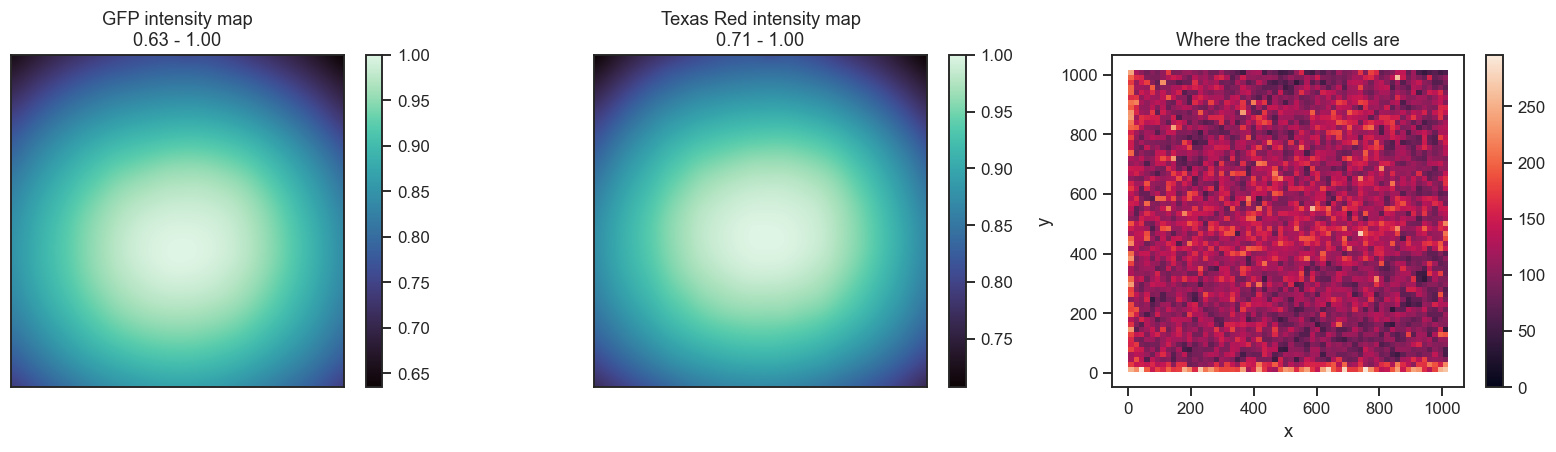

In [20]:
# The intensity map itself, as a picture, next to where the cells actually sit.
import tifffile
fig, axes = plt.subplots(1, len(CHANNELS) + 1, figsize=(5 * (len(CHANNELS) + 1), 4.2))
for ax, ch in zip(axes, CHANNELS):
    f = ROOT / used[(ch, "intensity")]
    m = tifffile.imread(f).astype(float)
    im = ax.imshow(m, cmap="mako")
    ax.set(title=f"{ch} intensity map\n{m.min():.2f} - {m.max():.2f}",
           xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, fraction=.046)

sns.histplot(data=cells, x="x", y="y", bins=60, cmap="rocket", cbar=True, ax=axes[-1])
axes[-1].set(title="Where the tracked cells are", xlabel="x", ylabel="y")
fig.tight_layout()
save(fig, "13_intensity_maps")

## 7. Export

In [21]:
out_xlsx = OUTDIR / "20250213_HT1080_pPS18_compiled.xlsx"
agg.export_to_excel_by_col(df, out_xlsx, by_column="code",
                           root_folder=ROOT, wellmap_path=ROOT / "platemap.csv")

tidy.to_csv(OUTDIR / "tidy_signal_by_stage.csv", index=False)
corr_df.to_csv(OUTDIR / "spearman_signal_vs_duration.csv", index=False)
verdict.to_csv(OUTDIR / "correction_map_audit.csv", index=False)
print(f"\nwrote {out_xlsx.name}, tidy_signal_by_stage.csv, "
      f"spearman_signal_vs_duration.csv, correction_map_audit.csv")
print(f"figures in {FIGDIR}")

Excel file saved to analysis_outputs/20250213_HT1080_pPS18/20250213_HT1080_pPS18_compiled.xlsx
Created 3 sheets (1 metadata + 1 code summary + 1 data sheets)

wrote 20250213_HT1080_pPS18_compiled.xlsx, tidy_signal_by_stage.csv, spearman_signal_vs_duration.csv, correction_map_audit.csv
figures in analysis_outputs/20250213_HT1080_pPS18/figures


## 8. What the run shows

**Texas Red predicts mitotic duration; GFP essentially does not.** Spearman
ρ ≈ 0.45 for Texas Red (p < 1e-30, n = 626), and ρ = 0.52 as the median of the
13 per-position correlations — so it is a within-field, per-cell relationship,
not a between-field offset. GFP gives ρ ≈ 0.07–0.09, marginal at best. The
Texas Red result is stable across every correction stage, which is the main
reason to believe it.

**The Texas Red relationship fits a Hill sigmoid.** EC50 ≈ 91 a.u., Hill
coefficient ≈ 1.6, rising from ≈ 48 min at low signal to ≈ 152 min at
saturation — a roughly three-fold extension of mitosis across the dosage range.
The same fit on GFP runs away to an EC50 three orders of magnitude beyond the
measured range, which is the fit's way of saying there is no sigmoid there.

**The broken correction moves the answer in both directions.** Under
`map bkg + int`, GFP's ρ inflates to 0.16 and Texas Red's deflates to 0.32.
Neither is real. This is the concrete cost of the map problem in section 3.

**Fate.** `dead_in_mitosis` cells spend significantly longer in mitosis
(median 80 vs 60 min; p = 2.6e-3 vs survivors, p = 4.6e-4 vs
`dead_post_mitosis`), while `dead_post_mitosis` is indistinguishable from
survivors (p = 0.28). So a long mitosis tracks death *in* mitosis specifically,
not death generally.

**The GFP intensity correction works. The Texas Red one over-corrects.** Both
channels fall off by ~12% from field centre to edge before correction
(edge/centre 0.89 GFP, 0.88 Texas Red). Afterwards GFP is flat (1.00) — textbook.
Texas Red instead *rises* to 1.11 at the edge: the gradient does not vanish, it
flips sign, so the map is applying roughly twice the correction it should. Note
that a max-minus-min "spread" statistic misses this entirely (12.4% → 11.8%,
apparently fine); only the signed edge/centre ratio shows it. Given that the
Texas Red maps are also the ambiguous ones in section 3, the first thing to try
is the fluorobrite well's map instead of the DMEM well's.

## 9. Caveats

**The correction maps need fixing at the source.** Three stale map files make
three of the four corrections ambiguous, and the background maps sit above the
cell signal in both channels. Until that is resolved, treat `int only` or
`emp bkg + int` as the working signal and ignore `map bkg + int`. Concretely:

```bash
# see the ambiguity the way the pipeline sees it
python pipeline.py check --root "<root>"
```

Delete the map files whose source well contradicts its role, then re-run the
affected positions with `--force` so the summaries are rebuilt against the
surviving maps.

**One condition on this plate.** All 13 positions are the same
celltype/transfection/drug, so nothing here is a treatment comparison — every
contrast is within-condition, across cells.

**`corrected_frames_in_mitosis` is quantized.** It counts frames, so at
`DELTA_T = 10` the duration is a multiple of 10 min. Bins narrower than that are
not meaningful, and Spearman is preferred over Pearson throughout because of the
ties this creates.

**No censoring on this plate, but check it on the next one.** The two filters
removed **0 of 626** tracks here: the longest mitosis is 470 min against a
137-frame (22.8 h) movie, so nothing ran off the end and every track had an
observed entry. On a plate with stronger arrest the filters would bite, and they
bias the duration distribution *downward* when they do — the longest arrests are
the ones most likely to be censored. `df_all` holds the unfiltered table.

**The empirical offset is a stand-in, not a calibration.** Subtracting the 2nd
percentile per position removes offset but also removes any genuine plate-wide
difference in baseline. It is the right move for asking *within* this plate
whether signal tracks duration; it is not a substitute for a working blank well.